In [1]:
from qiskit.synthesis import TwoQubitWeylDecomposition

In [2]:
from qiskit.circuit.library import UnitaryGate
import numpy as np

In [3]:
dim = 4
X = np.random.randn(2**dim, 2**dim) + 1j * np.random.randn(2**dim, 2**dim)
Q, R = np.linalg.qr(X)

D = np.diag(R)
U = Q @ np.diag(D / np.abs(D))
U

array([[ 0.17386173+6.65664182e-02j,  0.20428999-1.31657062e-01j,
         0.06124499-1.56181673e-01j,  0.01291921+2.31460324e-01j,
         0.25426499-6.76760835e-02j, -0.12948025+3.20097586e-01j,
         0.00548111+1.97002029e-02j,  0.11677154-2.41834110e-02j,
         0.15889948-2.99919101e-01j, -0.01184383+1.44552588e-01j,
        -0.29155596+1.68655756e-01j,  0.10558727-3.16389611e-01j,
        -0.06620282-2.83474182e-01j,  0.07826114+7.49868418e-02j,
         0.06626501-2.03835284e-01j,  0.13528872+3.15632003e-01j],
       [-0.29177239+2.72420716e-01j, -0.29427824-1.62565810e-01j,
         0.18326792+8.38643897e-02j,  0.04910613-4.35864616e-03j,
        -0.10978081-2.02792212e-01j,  0.04560722-2.05413560e-02j,
        -0.22386922-2.35324546e-01j, -0.15471939-1.13613271e-01j,
         0.13550471-9.35550486e-02j,  0.07140785+6.34244051e-02j,
         0.28544892+2.23074448e-01j, -0.05321453-3.62137308e-02j,
         0.03010936+5.96950386e-03j, -0.07092978+1.31762796e-01j,
         

In [4]:
from qiskit.synthesis import qs_decomposition

In [5]:
qs_decomposition(U).depth()

189

In [6]:
from qiskit import QuantumCircuit

In [7]:
UnitaryGate(U)

Instruction(name='unitary', num_qubits=4, num_clbits=0, params=[array([[ 0.17386173+6.65664182e-02j,  0.20428999-1.31657062e-01j,
         0.06124499-1.56181673e-01j,  0.01291921+2.31460324e-01j,
         0.25426499-6.76760835e-02j, -0.12948025+3.20097586e-01j,
         0.00548111+1.97002029e-02j,  0.11677154-2.41834110e-02j,
         0.15889948-2.99919101e-01j, -0.01184383+1.44552588e-01j,
        -0.29155596+1.68655756e-01j,  0.10558727-3.16389611e-01j,
        -0.06620282-2.83474182e-01j,  0.07826114+7.49868418e-02j,
         0.06626501-2.03835284e-01j,  0.13528872+3.15632003e-01j],
       [-0.29177239+2.72420716e-01j, -0.29427824-1.62565810e-01j,
         0.18326792+8.38643897e-02j,  0.04910613-4.35864616e-03j,
        -0.10978081-2.02792212e-01j,  0.04560722-2.05413560e-02j,
        -0.22386922-2.35324546e-01j, -0.15471939-1.13613271e-01j,
         0.13550471-9.35550486e-02j,  0.07140785+6.34244051e-02j,
         0.28544892+2.23074448e-01j, -0.05321453-3.62137308e-02j,
         0.

In [8]:
qc = QuantumCircuit(4)
qc.append(UnitaryGate(U), [0, 1, 2, 3])

qc.decompose().depth()

189

In [9]:
BASIS_GATES = ["cz", "id", "rx", "rz", "rzz", "sx", "x"]

COUPLING_MAP = [
    # poziome
    [0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11],[11,12],[12,13],[13,14],[14,15],
    [16,17],[17,18],[18,19],[19,20],[20,21],[21,22],[22,23],[23,24],[24,25],[25,26],[26,27],[27,28],[28,29],[29,30],[30,31],
    [32,33],[33,34],[34,35],[35,36],[36,37],[37,38],[38,39],[39,40],[40,41],[41,42],[42,43],[43,44],[44,45],[45,46],[46,47],
    [48,49],[49,50],[50,51],[51,52],[52,53],[53,54],[54,55],[55,56],[56,57],[57,58],[58,59],[59,60],[60,61],[61,62],[62,63],
    [64,65],[65,66],[66,67],[67,68],[68,69],[69,70],[70,71],[71,72],[72,73],[73,74],[74,75],[75,76],[76,77],[77,78],[78,79],
    [80,81],[81,82],[82,83],[83,84],[84,85],[85,86],[86,87],[87,88],[88,89],[89,90],[90,91],[91,92],[92,93],[93,94],[94,95],
    [96,97],[97,98],[98,99],[99,100],[100,101],[101,102],[102,103],[103,104],[104,105],[105,106],[106,107],[107,108],[108,109],[109,110],[110,111],
    [112,113],[113,114],[114,115],[115,116],[116,117],[117,118],[118,119],[119,120],[120,121],[121,122],[122,123],[123,124],[124,125],[125,126],[126,127],
    # pionowe
    [3,19],[7,23],[11,27],[15,31],
    [17,33],[21,37],[25,41],[29,45],
    [35,51],[39,55],[43,59],[47,63],
    [49,65],[53,69],[57,73],[61,77],
    [67,83],[71,87],[75,91],[79,95],
    [81,97],[85,101],[89,105],[93,109],
    [99,115],[103,119],[107,123],[111,127],
]

from qiskit import transpile

In [10]:
qctr = transpile(qc,
                 basis_gates=BASIS_GATES,
                 coupling_map=COUPLING_MAP,
                 optimization_level=3)

In [11]:
qctr.depth()

513

In [12]:
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins

In [13]:
list_stage_plugins("optimization")

['default']

In [14]:
from qiskit.transpiler import generate_preset_pass_manager

In [ ]:

pm_max = generate_preset_pass_manager(basis_gates=BASIS_GATES, optimization_level=3)

In [22]:
from qiskit import qpy

In [31]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/fourier_like/D110_F3_D111.qpy", "rb") as fd:
        benchqc = qpy.load(fd)[0]

In [52]:
qctest = pm.run(benchqc)
qcmax = pm_max.run(benchqc)

In [53]:
qctest.depth(), qcmax.depth()

(0, 42)

#TODO zrobic tak ze badac pare poziomow fidelity np 85, 90 i 95, i dla kazdego tego poziomu zbadac jak najnizszy approximation_degree w transpilatorze

In [47]:
from qiskit.quantum_info import state_fidelity, DensityMatrix, Operator, Statevector


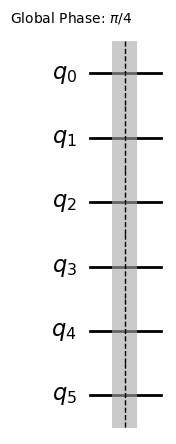

In [54]:
qctest.draw("mpl")

In [57]:
state_fidelity(DensityMatrix(qctest), DensityMatrix(qcmax))

0.03703703703704005

In [71]:
def fid_check(qc, qcmax):
    for i in range(10):
        pm = generate_preset_pass_manager(basis_gates=BASIS_GATES, optimization_level=3, approximation_degree=(i/100 + 0.9))
        qctest = pm.run(qc)
        print(f"arpox = {i/100 + 0.9}\nFid: {state_fidelity(DensityMatrix(qctest), DensityMatrix(qcmax))} \nDepth: {qctest.depth()}")

In [63]:
with open("C:/Users/szymo/QuditsOnQubits/QuditsOnQubits/data/benchmarks/circuits/baseline/E_old.qpy", "rb") as fd:
        baseqc = qpy.load(fd)[0]

In [64]:
qcbasemax = pm_max.run(baseqc)

In [65]:
qcbasemax.depth()

22

In [72]:
fid_check(baseqc, qcbasemax)

arpox = 0.9
Fid: 0.4451373773423677 
Depth: 19
arpox = 0.91
Fid: 0.878589832701324 
Depth: 19
arpox = 0.92
Fid: 0.878589832701324 
Depth: 19
arpox = 0.93
Fid: 0.878589832701324 
Depth: 19
arpox = 0.9400000000000001
Fid: 0.878589832701324 
Depth: 19
arpox = 0.9500000000000001
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.96
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.97
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.98
Fid: 0.9097895524833622 
Depth: 19
arpox = 0.99
Fid: 0.9908612100649324 
Depth: 19


In [3]:
from igraph import Graph, plot
import matplotlib.pyplot as plt

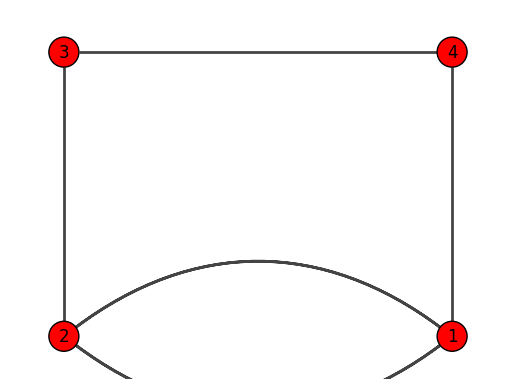

In [5]:
game43 = Graph(n=4, edges=[[0, 1], [0, 1],  [1, 2], [2, 3], [3, 0]])
game43.vs["name"] = [i+1 for i in range(game43.vcount())]
fig, ax = plt.subplots()
plot(game43, target=ax, vertex_label=game43.vs["name"])